## Klasifikasi Berita Detik (Hot, Health, Sport) — Vektor Skip-gram + Naive Bayes


## 1. Import Library

In [1]:
import re
import joblib
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Memuat 300 Data Berita Asli (Hot, Health, Sport)

Data ini sudah disiapkan sebelumnya (`df_berita_3kategori.csv`) — 100 judul asli per kategori, hasil crawling nyata dari detik.com, lengkap dengan URL aslinya.

In [2]:
df_berita = pd.read_csv('df_berita_3kategori.csv', index_col='No')

print("Jumlah total berita:", len(df_berita))
print("\nDistribusi kategori:")
print(df_berita['Kategori'].value_counts())
df_berita.head()

Jumlah total berita: 300

Distribusi kategori:
Kategori
hot       100
health    100
sport     100
Name: count, dtype: int64


,Judul Berita,Tautan,Kategori,Tanggal
No,,,,
1,"Eyangnya Meninggal, Kaesang Menyesal Belum Sem...",https://hot.detik.com/celeb/d-4954259/eyangnya...,hot,03/26/2020
2,Ada Empat Agensi yang Setuju X1 Tak Dibubarkan,https://hot.detik.com/detiktv/d-4852708/ada-em...,hot,01/09/2020
3,Jefri Nichol Bertarung dengan Nyai Roro Kidul,https://hot.detik.com/music/d-4942942/jefri-ni...,hot,03/17/2020
4,"Setelah Hoax Meninggal Dunia, Mamah Dedeh Sila...",https://hot.detik.com/celeb/d-5035507/setelah-...,hot,05/31/2020
5,Fenomena Datang ke Pernikahan Mantan di 'Temen...,https://hot.detik.com/detiktv/d-4877975/fenome...,hot,01/29/2020


## 3. Preprocessing & Tokenisasi Judul Berita

In [3]:
def tokenisasi(teks: str):
    teks = str(teks).lower()
    tokens = re.findall(r'[a-zA-Z]+', teks)
    return tokens

corpus = [tokenisasi(judul) for judul in df_berita['Judul Berita']]

print("Contoh hasil tokenisasi:")
for i in range(3):
    print(f"Judul : {df_berita['Judul Berita'].iloc[i]}")
    print(f"Token : {corpus[i]}\n")

vocab = sorted(set(w for tokens in corpus for w in tokens))
print(f"Jumlah kata unik (vocabulary): {len(vocab)}")

Contoh hasil tokenisasi:
Judul : Eyangnya Meninggal, Kaesang Menyesal Belum Sempat Kirim Sang Pisang
Token : ['eyangnya', 'meninggal', 'kaesang', 'menyesal', 'belum', 'sempat', 'kirim', 'sang', 'pisang']

Judul : Ada Empat Agensi yang Setuju X1 Tak Dibubarkan
Token : ['ada', 'empat', 'agensi', 'yang', 'setuju', 'x', 'tak', 'dibubarkan']

Judul : Jefri Nichol Bertarung dengan Nyai Roro Kidul
Token : ['jefri', 'nichol', 'bertarung', 'dengan', 'nyai', 'roro', 'kidul']

Jumlah kata unik (vocabulary): 1472


## 4. Melatih Model Skip-gram pada Seluruh Korpus Judul Berita

- **`sg=1`** -> arsitektur **Skip-gram**.
- **`vector_size=100`** -> dimensi vektor tiap kata (dibuat lebih besar dari contoh 3-kalimat karena vocabulary & korpus di sini jauh lebih kaya/besar).
- **`window=4`**, **`min_count=2`** -> kata yang cuma muncul 1x diabaikan (noise), supaya embedding lebih stabil.

In [4]:
model_w2v = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=4,
    min_count=2,
    sg=1,           # sg=1 -> Skip-gram
    epochs=100,
    seed=42,
    workers=1
)

print("Model Skip-gram berhasil dilatih.")
print("Jumlah kata dalam vocabulary model:", len(model_w2v.wv.index_to_key))
print("Dimensi vektor tiap kata:", model_w2v.vector_size)

Model Skip-gram berhasil dilatih.
Jumlah kata dalam vocabulary model: 408
Dimensi vektor tiap kata: 100


## 5. Representasi Vektor Dokumen (Rata-rata Vektor Kata per Judul)

Naive Bayes butuh **satu vektor per judul berita** (bukan per kata). Teknik umum: representasikan tiap judul sebagai **rata-rata (mean pooling)** dari vektor skip-gram semua kata penyusunnya. Kata yang tidak dikenali model (karena `min_count=2`) diabaikan.

In [5]:
def vektor_dokumen(tokens, model):
    vektor_kata = [model.wv[w] for w in tokens if w in model.wv]
    if len(vektor_kata) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vektor_kata, axis=0)

X = np.array([vektor_dokumen(tokens, model_w2v) for tokens in corpus])
print("Bentuk matriks fitur (X):", X.shape, "-> (jumlah_judul, dimensi_vektor)")

contoh_vektor = pd.DataFrame(X[:5, :8], columns=[f'dim_{i+1}' for i in range(8)])
contoh_vektor.insert(0, 'Judul Berita', df_berita['Judul Berita'].iloc[:5].values)
contoh_vektor

Bentuk matriks fitur (X): (300, 100) -> (jumlah_judul, dimensi_vektor)


,Judul Berita,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
0,"Eyangnya Meninggal, Kaesang Menyesal Belum Sem...",-0.059549,-0.056364,0.029018,-0.002174,-0.207634,0.154435,0.172496,0.122358
1,Ada Empat Agensi yang Setuju X1 Tak Dibubarkan,0.040041,0.014679,-0.279477,0.080957,-0.109498,0.066021,0.198657,0.099388
2,Jefri Nichol Bertarung dengan Nyai Roro Kidul,-0.354687,-0.075761,-0.056195,0.150937,-0.071211,0.266127,0.373328,-0.017297
3,"Setelah Hoax Meninggal Dunia, Mamah Dedeh Sila...",-0.021192,-0.026618,-0.043551,0.059323,-0.205510,0.100561,0.079388,0.083592
4,Fenomena Datang ke Pernikahan Mantan di 'Temen...,-0.126617,-0.047506,-0.107845,0.033658,-0.222680,0.136381,0.175786,0.170115


## 6. Split Data Latih & Uji

Karena datanya sudah cukup besar (300 baris), split train/test standar (80:20, stratified) sudah cukup stabil (beda dengan notebook 3-kalimat yang terlalu kecil untuk split biasa).

In [6]:
y = df_berita['Kategori'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Kelas:", list(le.classes_))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Kelas: ['health', 'hot', 'sport']
Jumlah data latih: 240
Jumlah data uji  : 60


## 7. Klasifikasi dengan Naive Bayes

In [7]:
clf = GaussianNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Model Naive Bayes berhasil dilatih.")

Model Naive Bayes berhasil dilatih.


## 8. Evaluasi Model

In [8]:
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi pada data uji: {akurasi:.4f} ({akurasi*100:.1f}%)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=[f"Aktual: {c}" for c in le.classes_],
                          columns=[f"Prediksi: {c}" for c in le.classes_])
df_cm

Akurasi pada data uji: 0.6667 (66.7%)

Classification Report:
              precision    recall  f1-score   support

      health       0.59      0.80      0.68        20
         hot       0.69      0.55      0.61        20
       sport       0.76      0.65      0.70        20

    accuracy                           0.67        60
   macro avg       0.68      0.67      0.66        60
weighted avg       0.68      0.67      0.66        60

Confusion Matrix:


,Prediksi: health,Prediksi: hot,Prediksi: sport
Aktual: health,16,4,0
Aktual: hot,5,11,4
Aktual: sport,6,1,13


## 8b. Visualisasi

Angka-angka evaluasi di atas penting, tapi visualisasi membantu memahami **mengapa** model berperforma seperti itu — apakah kategorinya memang sulit dipisahkan, atau modelnya cuma salah di beberapa kasus spesifik.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### Visualisasi 1 — Distribusi Jumlah Data per Kategori

Mengecek apakah data latih seimbang antar kategori (penting! kategori yang kurang terwakili biasanya diprediksi lebih buruk).

/tmp/ipykernel_118/3713749911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_berita, x='Kategori', order=urutan_kategori, palette='Set2')


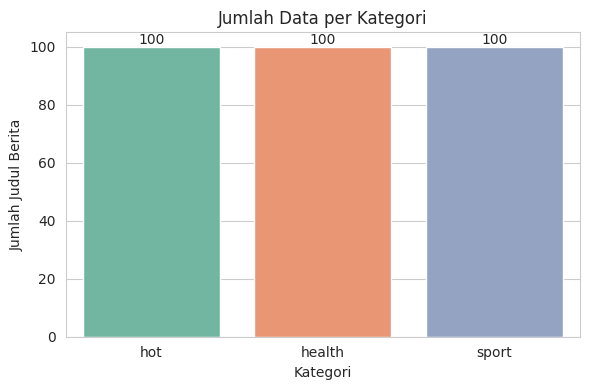

In [10]:
plt.figure(figsize=(6, 4))
urutan_kategori = df_berita['Kategori'].value_counts().index
ax = sns.countplot(data=df_berita, x='Kategori', order=urutan_kategori, palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Jumlah Data per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Judul Berita')
plt.tight_layout()
plt.savefig('viz_distribusi_kategori.png', bbox_inches='tight')
plt.show()

### Visualisasi 2 — Sebaran Vektor Dokumen (PCA 2D)

Vektor skip-gram tiap judul berdimensi 100 — tidak bisa dilihat langsung oleh mata. **PCA** dipakai untuk mereduksi ke 2 dimensi supaya bisa diplot. Kalau titik-titik dengan warna sama cenderung mengelompok (bukan tercampur acak), artinya fitur vektor skip-gram memang menangkap perbedaan topik antar kategori — ini alasan *kenapa* model bisa (atau tidak bisa) mengklasifikasi dengan baik.

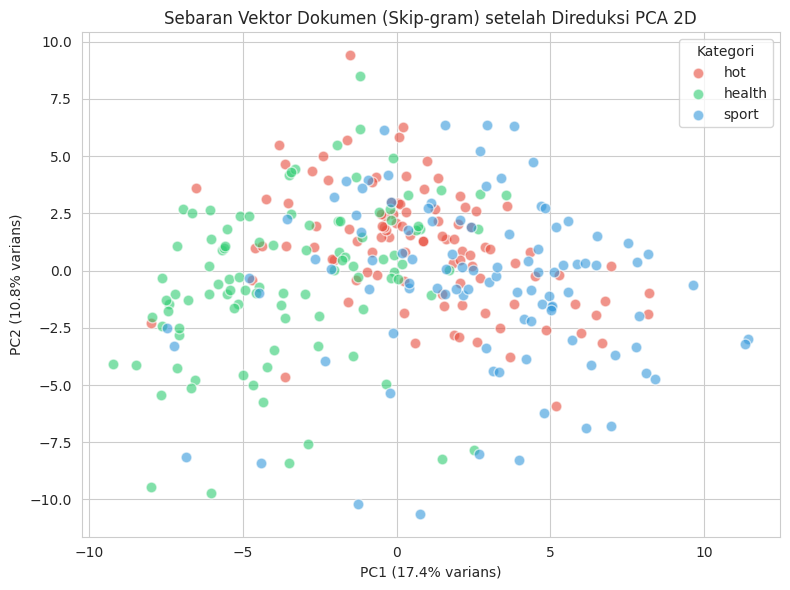

In [11]:
pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palet = {'health': '#2ecc71', 'hot': '#e74c3c', 'sport': '#3498db'}
for kategori in df_berita['Kategori'].unique():
    mask = df_berita['Kategori'].values == kategori
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=kategori,
                color=palet.get(kategori), alpha=0.6, edgecolor='white', s=60)

plt.title('Sebaran Vektor Dokumen (Skip-gram) setelah Direduksi PCA 2D')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.legend(title='Kategori')
plt.tight_layout()
plt.savefig('viz_sebaran_vektor_pca.png', bbox_inches='tight')
plt.show()

### Visualisasi 3 — Confusion Matrix (Heatmap)

Versi visual dari tabel confusion matrix di Bagian 8 — warna gelap di diagonal = prediksi benar, warna gelap di luar diagonal = kesalahan yang sering terjadi.

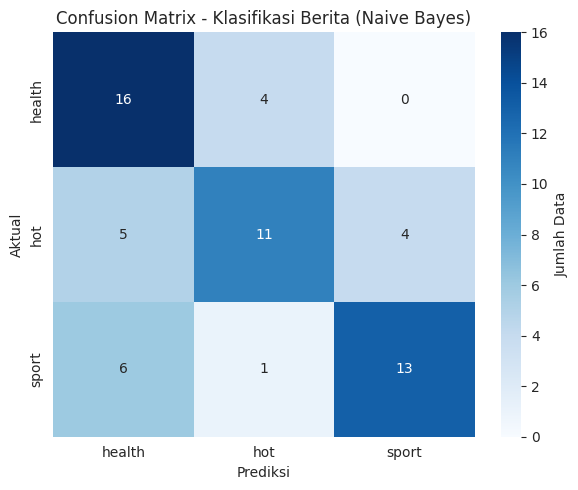

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Jumlah Data'})
plt.title('Confusion Matrix - Klasifikasi Berita (Naive Bayes)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('viz_confusion_matrix.png', bbox_inches='tight')
plt.show()

### Visualisasi 4 — Perbandingan Precision, Recall, F1-score per Kategori

Melihat kategori mana yang paling "gampang" vs paling "susah" diprediksi model secara lebih rinci daripada cuma accuracy keseluruhan.

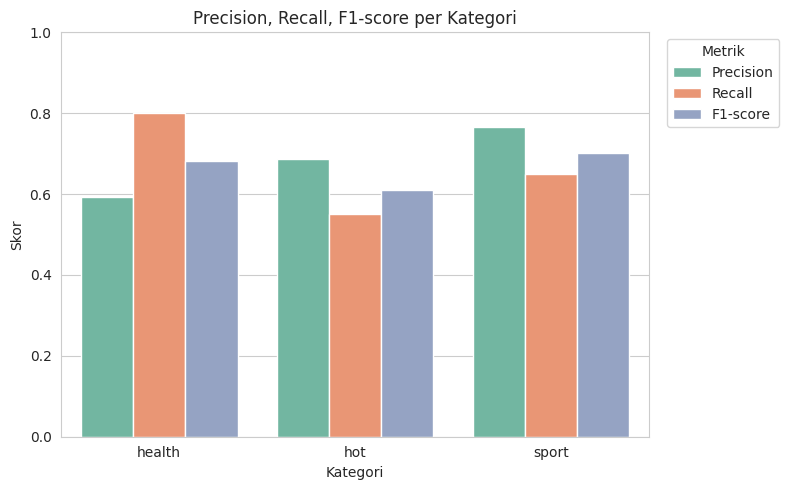

In [13]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=range(len(le.classes_)))

df_metrik = pd.DataFrame({
    'Kategori': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}).melt(id_vars='Kategori', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_metrik, x='Kategori', y='Skor', hue='Metrik', palette='Set2')
plt.title('Precision, Recall, F1-score per Kategori')
plt.ylim(0, 1)
plt.legend(title='Metrik', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('viz_metrik_per_kategori.png', bbox_inches='tight')
plt.show()

### Visualisasi 5 — Kata-kata yang Paling Mirip (Uji Kualitas Embedding Skip-gram)

Sebelum lanjut ke penyimpanan hasil, kita cek dulu apakah embedding skip-gram yang dilatih sudah menangkap makna kata dengan masuk akal.

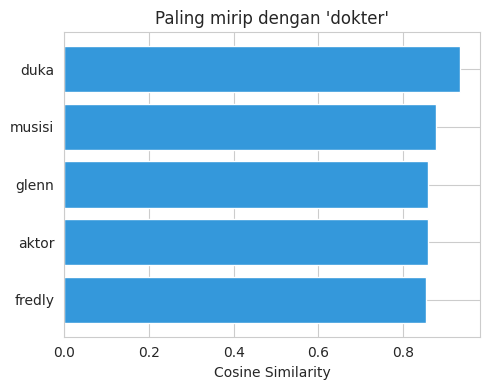

In [14]:
kata_uji = ['sepak', 'dokter', 'artis']
kata_uji = [k for k in kata_uji if k in model_w2v.wv]

fig, axes = plt.subplots(1, len(kata_uji), figsize=(5*len(kata_uji), 4))
if len(kata_uji) == 1:
    axes = [axes]

for ax, kata in zip(axes, kata_uji):
    mirip = model_w2v.wv.most_similar(kata, topn=5)
    kata_mirip = [m[0] for m in mirip]
    skor = [m[1] for m in mirip]
    ax.barh(kata_mirip, skor, color='#3498db')
    ax.set_title(f"Paling mirip dengan '{kata}'")
    ax.set_xlabel('Cosine Similarity')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('viz_kata_mirip.png', bbox_inches='tight')
plt.show()

## 9. Menyimpan Hasil ke CSV

In [15]:
idx_test = np.arange(len(df_berita))[-len(y_test):]  # placeholder, diganti di bawah dengan cara yang benar

# Cara yang benar: lacak index asli lewat train_test_split
_, idx_test = train_test_split(
    np.arange(len(df_berita)), test_size=0.2, random_state=42, stratify=y_encoded
)

df_hasil = pd.DataFrame({
    'Judul Berita': df_berita['Judul Berita'].values[idx_test],
    'Kategori_Asli': le.inverse_transform(y_test),
    'Kategori_Prediksi': le.inverse_transform(y_pred),
    'Benar': y_test == y_pred
})
df_hasil.to_csv('hasil_klasifikasi_berita.csv', index=False)
print("Tersimpan: 'hasil_klasifikasi_berita.csv' ->", df_hasil.shape)
df_hasil.head(10)

Tersimpan: 'hasil_klasifikasi_berita.csv' -> (60, 4)


,Judul Berita,Kategori_Asli,Kategori_Prediksi,Benar
0,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh ...",health,health,True
1,Viral Surat Terbuka Guru Besar UGM Sebut AC Pe...,health,health,True
2,Polemik 10 Cabor PON 2020 Berpeluang Tak Digel...,sport,sport,True
3,"UFC di Tengah Pandemi, Sebuah Pelarian yang Ta...",sport,health,False
4,"Usai Kalahkan Cerrone, McGregor Diajak Rematch...",sport,sport,True
5,Trump Klaim Punya Bukti Kuat Virus Corona Bera...,health,health,True
6,Dokumenter Tragedi Kapal Sewol 'In the Absence...,hot,sport,False
7,"Kenali Alkylglycerols, Zat Ampuh Perkuat Imuni...",health,hot,False
8,"Alex Akan Didepak, Marc Marquez Pertimbangkan ...",sport,sport,True
9,"48 Meninggal dari 514 Kasus, Tingkat Kematian ...",health,health,True


In [16]:
# Simpan juga representasi vektor dokumen lengkap (semua 300 berita, 100 dimensi) ke CSV
df_vektor_dok = pd.DataFrame(X, columns=[f'dim_{i+1}' for i in range(X.shape[1])])
df_vektor_dok.insert(0, 'Kategori', df_berita['Kategori'].values)
df_vektor_dok.insert(0, 'Judul Berita', df_berita['Judul Berita'].values)
df_vektor_dok.to_csv('vektor_dokumen_berita.csv', index=False)
print("Tersimpan: 'vektor_dokumen_berita.csv' ->", df_vektor_dok.shape)

Tersimpan: 'vektor_dokumen_berita.csv' -> (300, 102)


## 10. Menyimpan Model Terbaik untuk Deployment (Streamlit)

Supaya aplikasi Streamlit bisa mengklasifikasi judul berita baru tanpa harus melatih ulang dari nol, **3 komponen** perlu disimpan ke file:
1. **Model Skip-gram (Word2Vec)** -> untuk mengubah kata-kata baru menjadi vektor.
2. **Scaler (StandardScaler)** -> supaya skala fitur input baru konsisten dengan data latih.
3. **Model Naive Bayes + LabelEncoder** -> untuk melakukan prediksi kategori & mengubah hasil angka kembali ke label aslinya (`hot`/`health`/`sport`).

Model dilatih ulang sekali lagi dengan **seluruh 300 data** (bukan cuma 80% data latih) sebelum disimpan, supaya model final yang di-deploy memakai semua informasi yang ada (praktik umum setelah proses evaluasi selesai dan hasilnya memuaskan).

In [17]:
# Latih ulang Naive Bayes dengan SELURUH data (bukan cuma 80% training split)
# -> ini model FINAL yang akan dipakai untuk deployment
clf_final = GaussianNB()
clf_final.fit(X_scaled, y_encoded)

print("Model final (dilatih dengan seluruh 300 data) siap disimpan.")
print(f"Akurasi model final pada seluruh data latih: {clf_final.score(X_scaled, y_encoded):.4f}")
print("(Catatan: angka ini BUKAN akurasi evaluasi yang valid karena diuji di data yang sama")
print(" dengan yang dipakai latih -> akurasi evaluasi yang valid tetap yang di Bagian 8 di atas)")

Model final (dilatih dengan seluruh 300 data) siap disimpan.
Akurasi model final pada seluruh data latih: 0.7233
(Catatan: angka ini BUKAN akurasi evaluasi yang valid karena diuji di data yang sama
 dengan yang dipakai latih -> akurasi evaluasi yang valid tetap yang di Bagian 8 di atas)


In [18]:
# 1. Simpan model Skip-gram (Word2Vec) - pakai format native gensim (.model)
model_w2v.save('model_skipgram.model')

# 2. Simpan scaler
joblib.dump(scaler, 'scaler.pkl')

# 3. Simpan model Naive Bayes final + label encoder
joblib.dump(clf_final, 'model_naive_bayes.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Semua komponen model berhasil disimpan:")
print("  - model_skipgram.model   (Word2Vec Skip-gram)")
print("  - scaler.pkl             (StandardScaler)")
print("  - model_naive_bayes.pkl  (GaussianNB final)")
print("  - label_encoder.pkl      (LabelEncoder: hot/health/sport)")
print("\nKeempat file ini WAJIB disertakan satu folder dengan app.py Streamlit.")

Semua komponen model berhasil disimpan:
  - model_skipgram.model   (Word2Vec Skip-gram)
  - scaler.pkl             (StandardScaler)
  - model_naive_bayes.pkl  (GaussianNB final)
  - label_encoder.pkl      (LabelEncoder: hot/health/sport)

Keempat file ini WAJIB disertakan satu folder dengan app.py Streamlit.


In [19]:
# Uji cepat: pastikan model yang baru disimpan bisa dimuat ulang & dipakai memprediksi
model_w2v_test = Word2Vec.load('model_skipgram.model')
scaler_test = joblib.load('scaler.pkl')
clf_test = joblib.load('model_naive_bayes.pkl')
le_test = joblib.load('label_encoder.pkl')

judul_baru = "Timnas Indonesia menang telak di laga final sepak bola"
tokens_baru = tokenisasi(judul_baru)
vek_baru = vektor_dokumen(tokens_baru, model_w2v_test).reshape(1, -1)
vek_baru_scaled = scaler_test.transform(vek_baru)
prediksi = clf_test.predict(vek_baru_scaled)
label_prediksi = le_test.inverse_transform(prediksi)[0]

print(f"Judul uji  : {judul_baru}")
print(f"Prediksi   : {label_prediksi}")
print("\n(Model berhasil dimuat ulang dari file & bisa memprediksi data baru -> siap untuk deployment)")

Judul uji  : Timnas Indonesia menang telak di laga final sepak bola
Prediksi   : sport

(Model berhasil dimuat ulang dari file & bisa memprediksi data baru -> siap untuk deployment)


## 11. Kesimpulan

- 300 judul berita **asli** dari detik.com (100 `hot` + 100 `health` + 100 `sport`) berhasil diklasifikasikan menggunakan representasi **vektor Skip-gram** (rata-rata vektor kata per judul) sebagai fitur dan **Naive Bayes (GaussianNB)** sebagai model klasifikasi.
- Hasil evaluasi (accuracy, precision, recall, F1, confusion matrix) ada di Bagian 8.
- **4 file model** berhasil disimpan untuk deployment: `model_skipgram.model`, `scaler.pkl`, `model_naive_bayes.pkl`, `label_encoder.pkl` — siap dipakai oleh aplikasi Streamlit (`app.py`) untuk mengklasifikasi judul berita baru secara real-time tanpa perlu melatih ulang model.